# Multi-Modal Deep Neural Network (DNN) with Class-Weight Balancing

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/chess_project/"

import pandas as pd
import numpy as np

df = pd.read_parquet(base_path + "chess_scalar.parquet")

print("Scalar shape:", df.shape)
print(df.head())

df.iloc[0,:]

# frequency count of each label
print(df["label"].value_counts())

X_tensor = np.load(base_path + "chess_tensor.npy")
print("Tensor shape:", X_tensor.shape)

X_tensor[0]


from sklearn.preprocessing import LabelEncoder
import tensorflow as tf

le = LabelEncoder()
y_encoded = le.fit_transform(df["label"])

y = tf.keras.utils.to_categorical(y_encoded)

print("Classes:", le.classes_)

# columns to REMOVE (leakage features)
leak_cols = ["label", "delta", "eval", "piece_moved", "is_capture", "gives_check"]

# build X_scalar without them
X_scalar = df.drop(columns=leak_cols).values
print("Scalar input shape:", X_scalar.shape)

#Class weights (Handling Imbalanced Data)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# convert one-hot y → class indices
y_indices = np.argmax(y, axis=1)

# get unique classes
classes = np.unique(y_indices)

# compute weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_indices
)

# convert to dictionary (required by keras)
class_weights_dict = dict(zip(classes, class_weights))
print(df["label"].value_counts())
print("Classes:", le.classes_)
print(class_weights_dict)

from sklearn.model_selection import train_test_split

# split all together to keep alignment
X_tensor_train, X_tensor_test, X_scalar_train, X_scalar_test, y_train, y_test = train_test_split(
    X_tensor,
    X_scalar,
    y,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(y, axis=1)   # ✅ keeps class distribution same
)
print("Train shape:", X_tensor_train.shape, X_scalar_train.shape, y_train.shape)
print("Test shape:", X_tensor_test.shape, X_scalar_test.shape, y_test.shape)


#scaling scalar features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scalar_train = scaler.fit_transform(X_scalar_train)
X_scalar_test = scaler.transform(X_scalar_test)

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from itertools import product
import pandas as pd


Mounted at /content/drive
Scalar shape: (337981, 21)
   move_number  turn  en_passant  halfmove_clock  is_check  mobility  \
0            1     1          -1               0         0        20   
1            2     0          -1               0         0        20   
2            3     1          -1               0         0        30   
3            4     0          -1               0         0        21   
4            5     1          -1               1         0        38   

   material_balance  piece_moved  is_capture  gives_check  ...  prev_delta  \
0                 0            1           0            0  ...           0   
1                 0            1           0            0  ...           0   
2                 0            1           0            0  ...          25   
3                 0            3           0            0  ...          -2   
4                 0            3           0            0  ...           7   

   eval  delta  elo_diff  avg_elo  castle_K  

In [ ]:
X_tensor_train[0]

array([[[0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 0, 0, 0]],

       [[0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0]],

       [[0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0]],

       [[0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        

In [ ]:
X_scalar_train[0]

array([ 1.66672115, -1.00808046, -0.03553803, -0.54124798, -0.27620286,
       -0.77662   ,  3.43567369,  0.44883378,  0.03349671,  3.10311642,
        0.42378142, -0.66578667, -0.66134665, -0.70325023, -0.69393078])

In [ ]:
# Flatten 4D tensors down to 2D matrices: (samples, 12 * 8 * 8) -> (samples, 768)
X_tensor_train_flat = X_tensor_train.reshape(X_tensor_train.shape[0], -1)
X_tensor_test_flat = X_tensor_test.reshape(X_tensor_test.shape[0], -1)

# Horizontally stack features: 768 tensor features + 15 scalar features = 783 total features
X_train = np.concatenate([X_tensor_train_flat, X_scalar_train], axis=1)
X_test = np.concatenate([X_tensor_test_flat, X_scalar_test], axis=1)

print(f"📊 Training shape: {X_train.shape}")
print(f"📊 Testing shape:  {X_test.shape}")


# ==========================================
# 2. MODEL BUILDER
# ==========================================

def build_model(input_dim, dense_units, dropout_rate, optimizer, lr):
    model = models.Sequential()

    # -------- input layer --------
    model.add(layers.Dense(dense_units, activation='relu', input_shape=(input_dim,)))
    model.add(layers.BatchNormalization())

    # -------- hidden layers --------
    model.add(layers.Dense(dense_units, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(dense_units//2, activation='relu'))
    model.add(layers.Dropout(dropout_rate))

    # -------- output layer (uses your actual 'le' object) --------
    model.add(layers.Dense(len(le.classes_), activation='softmax'))

    # -------- optimizer --------
    if optimizer == "adam":
        opt = tf.keras.optimizers.Adam(learning_rate=lr)
    elif optimizer == "rmsprop":
        opt = tf.keras.optimizers.RMSprop(learning_rate=lr)
    elif optimizer == "sgd":
        opt = tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9)

    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# ==========================================
# 3. HYPERPARAMETER GRID
# ==========================================

dense_units_list = [128, 256]
dropout_list = [0.3, 0.5]
optimizers = ["adam", "rmsprop"]
lr_list = [0.001, 0.0005]
batch_sizes = [64, 128]

combinations = list(product(dense_units_list, dropout_list, optimizers, lr_list, batch_sizes))


# ==========================================
# 4. TRAINING LOOP
# ==========================================

results = []
best_acc = 0
best_config = None
best_model = None

for i, (d, dr, opt, lr, bs) in enumerate(combinations):

    print(f"\n🔹 Config {i+1}/{len(combinations)}")
    print(f"dense={d}, dropout={dr}, opt={opt}, lr={lr}, batch={bs}")

    # Passes X_train.shape[1] (783) dynamically as the input dimension
    model = build_model(X_train.shape[1], d, dr, opt, lr)

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=20,
        batch_size=bs,
        callbacks=[early_stop],
        verbose=0
    )

    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    print(f"✅ Accuracy: {acc:.4f}")

    results.append({
        "dense": d,
        "dropout": dr,
        "optimizer": opt,
        "lr": lr,
        "batch_size": bs,
        "accuracy": acc
    })

    if acc > best_acc:
        best_acc = acc
        best_config = results[-1]
        best_model = model


# ==========================================
# 5. RESULTS DISPLAY
# ==========================================

results_df = pd.DataFrame(results)

print("\n📊 All Results:")
print(results_df.sort_values(by="accuracy", ascending=False).to_string(index=False))

print("\n🏆 Best Config:")
for key, value in best_config.items():
    print(f"  {key}: {value}")

print(f"\n🔥 Best Accuracy: {best_acc:.4f}")

📊 Training shape: (270384, 783)
📊 Testing shape:  (67597, 783)

🔹 Config 1/32
dense=128, dropout=0.3, opt=adam, lr=0.001, batch=64
✅ Accuracy: 0.6581

🔹 Config 2/32
dense=128, dropout=0.3, opt=adam, lr=0.001, batch=128
✅ Accuracy: 0.6558

🔹 Config 3/32
dense=128, dropout=0.3, opt=adam, lr=0.0005, batch=64
✅ Accuracy: 0.6599

🔹 Config 4/32
dense=128, dropout=0.3, opt=adam, lr=0.0005, batch=128
✅ Accuracy: 0.6591

🔹 Config 5/32
dense=128, dropout=0.3, opt=rmsprop, lr=0.001, batch=64
✅ Accuracy: 0.6572

🔹 Config 6/32
dense=128, dropout=0.3, opt=rmsprop, lr=0.001, batch=128
✅ Accuracy: 0.6584

🔹 Config 7/32
dense=128, dropout=0.3, opt=rmsprop, lr=0.0005, batch=64
✅ Accuracy: 0.6585

🔹 Config 8/32
dense=128, dropout=0.3, opt=rmsprop, lr=0.0005, batch=128
✅ Accuracy: 0.6565

🔹 Config 9/32
dense=128, dropout=0.5, opt=adam, lr=0.001, batch=64
✅ Accuracy: 0.6548

🔹 Config 10/32
dense=128, dropout=0.5, opt=adam, lr=0.001, batch=128
✅ Accuracy: 0.6590

🔹 Config 11/32
dense=128, dropout=0.5, opt=a

## best model summary

In [4]:
pip install pydot graphviz


   -------------------- ------------------- 1/2 [graphviz]
   ---------------------------------------- 2/2 [graphviz]

Note: you may need to restart the kernel to use updated packages.



========== DETAILED MODEL SUMMARY ==========



Model: "Chess_Classifier_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━
┃ Layer (type)                                  ┃ Output Shape                        ┃            Param # ┃ Traina
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━
│ Input_Dense (Dense)                           │ (None, 256)                         │            200,704 │     Y 
├───────────────────────────────────────────────┼─────────────────────────────────────┼────────────────────┼───────
│ BatchNorm_1 (BatchNormalization)              │ (None, 256)                         │              1,024 │     Y 
├───────────────────────────────────────────────┼─────────────────────────────────────┼────────────────────┼───────
│ Hidden_Dense_1 (Dense)                        │ (None, 256)                         │             65,792 │     Y 
├───────────────────────────────────────────────┼─────────────────────────────────────┼────────────────────┼───────
│ BatchNorm_2 (BatchNormalization)              │ (None, 256)                         │              1,024 │     Y 
├───────────────────────────────────────────────┼─────────────────────────────────────┼────────────────────┼───────
│ Dropout_1 (Dropout)                           │ (None, 256)                         │                  0 │     - 
├───────────────────────────────────────────────┼─────────────────────────────────────┼────────────────────┼───────
│ Hidden_Dense_2 (Dense)                        │ (None, 128)                         │             32,896 │     Y 
├───────────────────────────────────────────────┼─────────────────────────────────────┼────────────────────┼───────
│ Dropout_2 (Dropout)                           │ (None, 128)                         │                  0 │     - 
├───────────────────────────────────────────────┼─────────────────────────────────────┼────────────────────┼───────
│ Output_Layer (Dense)                          │ (None, 5)                           │                645 │     Y 
└───────────────────────────────────────────────┴─────────────────────────────────────┴────────────────────┴───────

 Total params: 302,085 (1.15 MB)

 Trainable params: 301,061 (1.15 MB)

 Non-trainable params: 1,024 (4.00 KB)


========== MODEL INPUT / OUTPUT ==========

Model Input Shape  : (None, 783)
Model Output Shape : (None, 5)

========== LAYER-WISE DETAILS ==========


Layer 1
Name         : Input_Dense
Type         : Dense
Input Shape  : (None, 783)
Output Shape : (None, 256)
Parameters   : 200704

Layer 2
Name         : BatchNorm_1
Type         : BatchNormalization
Input Shape  : (None, 256)
Output Shape : (None, 256)
Parameters   : 1024

Layer 3
Name         : Hidden_Dense_1
Type         : Dense
Input Shape  : (None, 256)
Output Shape : (None, 256)
Parameters   : 65792

Layer 4
Name         : BatchNorm_2
Type         : BatchNormalization
Input Shape  : (None, 256)
Output Shape : (None, 256)
Parameters   : 1024

Layer 5
Name         : Dropout_1
Type         : Dropout
Input Shape  : (None, 256)
Output Shape : (None, 256)
Parameters   : 0

Layer 6
Name         : Hidden_Dense_2
Type         : Dense
Input Shape  : (None, 256)
Output Shape : (None, 128)
Parameters   : 32896

Layer 7
Name         : Dropo

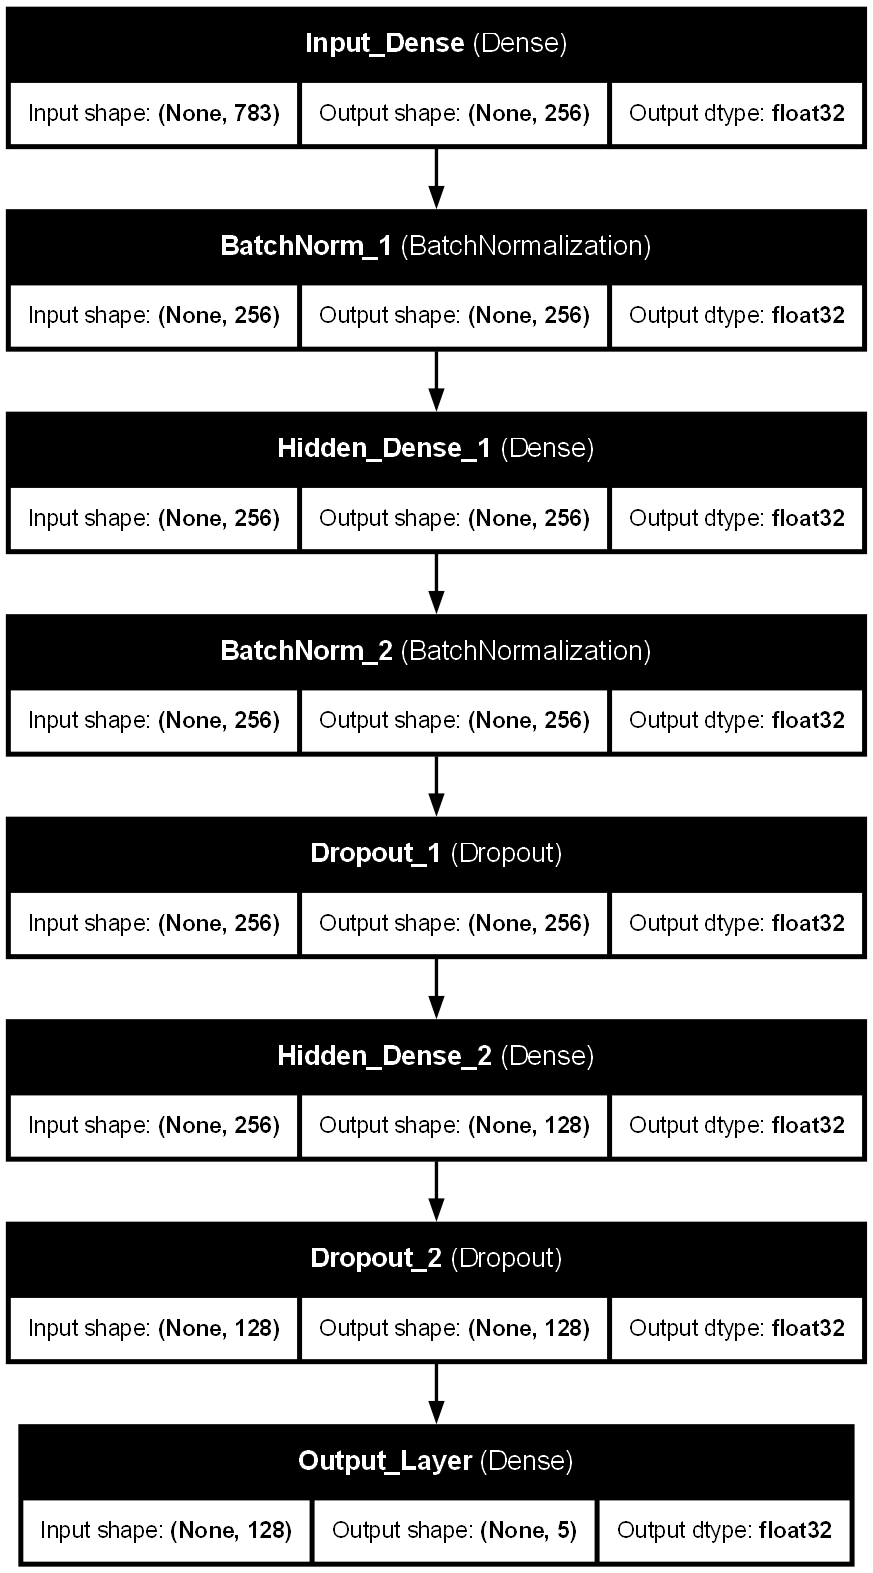

In [2]:
# ==========================================
# IMPORTS
# ==========================================

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import plot_model

# ==========================================
# BEST MODEL PARAMETERS
# ==========================================

best_dense = 256
best_dropout = 0.3
best_lr = 0.0005

# ==========================================
# INPUT / OUTPUT INFO
# ==========================================

input_dim = 783
num_classes = 5

# ==========================================
# BUILD MODEL
# ==========================================

model = models.Sequential(name="Chess_Classifier_Model")

# Input Layer
model.add(
    layers.Dense(
        best_dense,
        activation='relu',
        input_shape=(input_dim,),
        name="Input_Dense"
    )
)

model.add(
    layers.BatchNormalization(
        name="BatchNorm_1"
    )
)

# Hidden Layer 1
model.add(
    layers.Dense(
        best_dense,
        activation='relu',
        name="Hidden_Dense_1"
    )
)

model.add(
    layers.BatchNormalization(
        name="BatchNorm_2"
    )
)

model.add(
    layers.Dropout(
        best_dropout,
        name="Dropout_1"
    )
)

# Hidden Layer 2
model.add(
    layers.Dense(
        best_dense // 2,
        activation='relu',
        name="Hidden_Dense_2"
    )
)

model.add(
    layers.Dropout(
        best_dropout,
        name="Dropout_2"
    )
)

# Output Layer
model.add(
    layers.Dense(
        num_classes,
        activation='softmax',
        name="Output_Layer"
    )
)

# ==========================================
# COMPILE MODEL
# ==========================================

optimizer = tf.keras.optimizers.Adam(
    learning_rate=best_lr
)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================================
# PRINT DETAILED MODEL SUMMARY
# ==========================================

print("\n========== DETAILED MODEL SUMMARY ==========\n")

model.summary(
    line_length=120,
    expand_nested=True,
    show_trainable=True
)

# ==========================================
# PRINT INPUT / OUTPUT SHAPES
# ==========================================

print("\n========== MODEL INPUT / OUTPUT ==========\n")

print(f"Model Input Shape  : {model.input_shape}")

print(f"Model Output Shape : {model.output_shape}")

# ==========================================
# SHOW EACH LAYER DETAILS
# ==========================================

print("\n========== LAYER-WISE DETAILS ==========\n")

for i, layer in enumerate(model.layers):

    print(f"\nLayer {i+1}")

    print(f"Name         : {layer.name}")

    print(f"Type         : {layer.__class__.__name__}")

    print(f"Input Shape  : {layer.input.shape}")

    print(f"Output Shape : {layer.output.shape}")

    print(f"Parameters   : {layer.count_params()}")

# ==========================================
# SAVE MODEL ARCHITECTURE IMAGE
# ==========================================

plot_model(
    model,
    to_file="model_architecture.png",
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    expand_nested=True,
    dpi=120
)


from IPython.display import Image

Image("model_architecture.png")